# COMPAS experiment

In [ ]:
from boundary_trace import GroupScoreDistribution, trace_intersection
from plotting import plot_feasible_regions
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Setup and data

In [ ]:
compas_url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'

df = pd.read_csv(compas_url)

df = df[(df.days_b_screening_arrest >= -30)
        & (df.days_b_screening_arrest <= 30)
        & (df.is_recid != -1)
        & (df.c_charge_degree != 'O')
        & (df.score_text != 'N/A')]

df = df[df.race.isin(['Caucasian', 'African-American'])]

Y = df.two_year_recid.to_numpy().astype(int)
A = np.where(df.race == 'Caucasian', 0, 1)
S = df.decile_score.to_numpy().astype(int) - 1

In [ ]:
# Define groupwise score distributions

scores_all = np.array([
    np.mean(Y[S == s])
    for s in range(10)])

weights0 = np.array([
    np.mean(S[A == 0] == s)
    for s in range(10)])

weights1 = np.array([
    np.mean(S[A == 1] == s)
    for s in range(10)])

dist0 = GroupScoreDistribution(scores_all, weights0, name='White')
dist1 = GroupScoreDistribution(scores_all, weights1, name='Black')

prob_a1 = np.mean(A)

## Boundary tracing and statistics

In [ ]:
# Unconstrained classifier

acc_unconstrained = (
    (1 - prob_a1) * np.maximum(dist0.s, 1 - dist0.s).dot(dist0.w)
    + prob_a1 * np.maximum(dist1.s, 1 - dist1.s).dot(dist1.w))
print(f'Unconstrained accuracy: {acc_unconstrained:.4f}')

for dist in [dist0, dist1]:
  accept = dist.s >= 0.5
  reject = ~accept

  p_unconstrained = dist.s[accept].dot(dist.w[accept]) / dist.w[accept].sum()
  q_unconstrained = dist.s[reject].dot(dist.w[reject]) / dist.w[reject].sum()

  print(f'Group: {dist.name}\n'
        f'  p = {p_unconstrained:.4f}, q = {q_unconstrained:.4f}')

Unconstrained accuracy: 0.6629
Group: White
  p = 0.6611, q = 0.3273
Group: Black
  p = 0.6807, q = 0.3620


In [ ]:
# Trace intersection boundary

result = trace_intersection(dist0, dist1, prob_a1)
print(result)

TraceResult(
  A=0: White,
  A=1: Black,
  prob_a1 = 0.6016,
  pi_agg  = 0.4704,
  max_acc:  value = 0.6563,
            p = 0.6446, q = 0.3346
  min_dsep: value = 0.1464,
            p = 0.6807, q = 0.3620
)


In [ ]:
# Accuracy at min_dsep

mu_dsep = (result.pi_agg - result.min_dsep.q) / (
    result.min_dsep.p - result.min_dsep.q)

acc_dsep = 1 - result.pi_agg + mu_dsep * (2 * result.min_dsep.p - 1)

print(f'Accuracy at min_dsep: {acc_dsep:.4f}')

Accuracy at min_dsep: 0.6526


In [ ]:
# Are the sufficient optima on the group-specific boundaries?

for dist in result.dists:
  print(f'Group: {dist.name}\n'
        f'  max_acc on boundary =  {dist.is_on_boundary(result.max_acc.p, result.max_acc.q)}\n'
        f'  min_dsep on boundary = {dist.is_on_boundary(result.min_dsep.p, result.min_dsep.q)}')

Group: White
  max_acc on boundary =  False
  min_dsep on boundary = False
Group: Black
  max_acc on boundary =  True
  min_dsep on boundary = True


## Figure

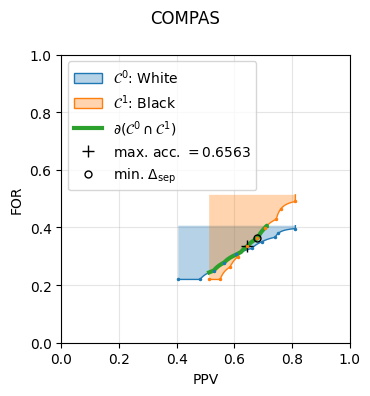

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

plot_feasible_regions(ax, result, show_breakpoints=True)

fig.suptitle('COMPAS')
fig.tight_layout()